# Тема
### **Построение нейросетевого классификатора для идентификации типа подстилающей поверхности при движении мобильного робота в условиях неоднородной среды**

Студент: **Массунда Жуниор Фернандо**

Группа: **8ЕМ51**

Вариант: **15** 
- Тип поверхности: **5**
- Использование переменных: **{V1, V2}**

# Цель работы
1. Приобретение практических навыков в решении одной из актуальных задач в построении интеллектуальной СУ автономной робототехнической системы, функционирующей в условиях физически неоднородной среды;
2. Практическое изучение особенностей и способов решения задачи несбалансированной
классификации, а также расширение инструментария разработчика в части работы с методами
машинного обучения;
3. Развитие исследовательских навыков работы с методом машинного обучения на примере прикладной задачи и реальной выборке данных;
4. Развитие навыков программирования систем вычислительного интеллекта на Python.

## Задачи
1. Построить нейросетевой классификатор (в соответствии с вариантом задания), протестированный и более-менее устойчивый к новым данным (самостоятельно осуществить проверку на выборке С); 
2. Приобрести опыт и понимание работы нейросетевого алгоритма в части влияния различных его параметров (числа слоев, нейронов в слое, числа итераций, функции активации, способа предобработки данных и т.п.) на качество получаемой модели.

# Ход работы

# **1. Импортирование библиотек**

In [2]:
# Импорт основных библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Импорт из sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Импорт наших функций из utils.py
import sys
import os

# Добавляем путь к папке src
current_dir = os.getcwd()
src_path = os.path.join(current_dir, '../Source')
sys.path.append(src_path)

print(f"Текущая директория: {current_dir}")
print(f"Путь к src: {src_path}")

try:
    from Utils_A import prepare_data_v1, prepare_data_v2, prepare_data_v1v2, calculate_v2_features, evaluate_model, plot_training_results, plot_test_results, V1_COLUMNS, V2_COLUMNS
    print("✓ Все библиотеки и функции успешно импортированы")
    print(f"✓ Используем признаки V1: {len(V1_COLUMNS)} признаков")
    print(f"✓ Используем признаки V2: {len(V2_COLUMNS)} признаков")
except ImportError as e:
    print(f"✗ Ошибка импорта: {e}")
    print("Проверьте, что файл utils.py находится в папке src/")
    print("Содержимое папки src:", os.listdir(src_path) if os.path.exists(src_path) else "Папка не существует")


Текущая директория: d:\HereAgain\CALOIRO 2025\Programming\LAB_MAI_02\Report
Путь к src: d:\HereAgain\CALOIRO 2025\Programming\LAB_MAI_02\Report\../Source
✓ Все библиотеки и функции успешно импортированы
✓ Используем признаки V1: 15 признаков
✓ Используем признаки V2: 7 признаков


# **2. Загрузка и анализ данных**
- Тип поверхности: 5  
- Признаки: V1 (15 признаков) и V2 (7 признаков)

1) **V1** - значения переменных, полученные непосредственно сенсорной системо (датчиков) робота (измеряемые )
    - **Исследование на V1**: Может ли нейронная сеть определить тип поверхности, используя только измеряемые значения?

2) **V2** - множество абсолютных параметров, полученных путем математических преобразований (расчетные)
    - **Исследование на V2**: Можно ли определить тип поверхности по интегральным характеристикам движения робота?

3) **V1 + V2** - сочетание V1 и V2
    - **Исследование на V1 + V2**: Улучшится ли качество классификации, если объединить исходные данные датчиков и интегральные характеристики движения?



БЛОК 2: ЗАГРУЗКА И АНАЛИЗ ДАННЫХ
✓ Данные загружены из: ..\Data\Data_Set_(A+B).xlsx
✓ Данные загружены: 176 строк, 16 столбцов
  Столбцы: ['I1', 'I2', 'I3', 'gx', 'gy', 'gz', 'ax', 'ay', 'az', 'V1real', 'V2real', 'V3real', 'N1', 'N2', 'N3', 'Type']
✓ Новые данные загружены: 176 строк, 23 столбцов
  Столбцы: ['I1', 'I2', 'I3', 'gx', 'gy', 'gz', 'ax', 'ay', 'az', 'V1real', 'V2real', 'V3real', 'N1', 'N2', 'N3', 'Type', 'Vx', 'Vy', 'Omega', 'Ix', 'Iy', 'Iphi', 'Isum']

ПЕРВЫЕ 5 СТРОК ДАННЫХ:
         I1        I2        I3        gx        gy        gz        ax  \
0  1.126697  0.021116  0.927601  0.712941 -0.252941  1.081765  0.043529   
1  1.039215  0.015083  0.953243  0.229412  0.276471  0.485294  0.013672   
2  0.911011  0.004525  0.947210  1.170588  0.222941  0.664118  0.011704   
3  0.692308  1.156862  0.550528  1.165294  0.698235 -3.421765  0.001321   
4  0.529412  1.024133  0.453997  0.808235  0.090000 -1.449412  0.006218   

         ay        az      V1real  ...    N2    N3  Typ

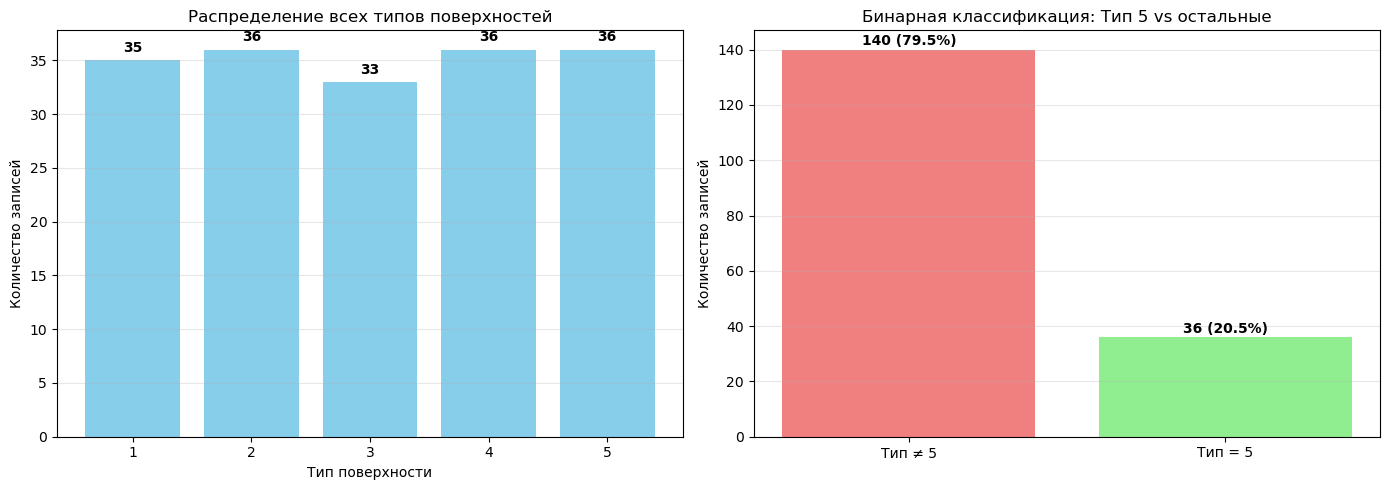


ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ О ПРИЗНАКАХ:

Диапазоны значений признаков V1:
  N1: [-5519.00, 14770.00]
  N2: [-8010.00, 14829.00]
  N3: [-72.00, 14554.00]
  V1real: [-300.60, 772.20]
  V2real: [-363.60, 768.60]

Проверка пропущенных значений:
  ✓ Нет пропущенных значений

Диапазоны значений признаков V2:
  Vx: [-534.46, 14341.38]
  Vy: [-336.00, 14832.00]
  Omega: [-7.49, 247.30]
  Ix: [-0.20, 0.38]
  Iy: [-0.36, 0.80]

Проверка пропущенных значений:
  ✓ Нет пропущенных значений

Диапазоны значений признаков V1 + V2:
  N1: [-5519.00, 14770.00]
  N2: [-8010.00, 14829.00]
  N3: [-72.00, 14554.00]
  V1real: [-300.60, 772.20]
  V2real: [-363.60, 768.60]

Проверка пропущенных значений:
  ✓ Нет пропущенных значений

БЛОК 2 ЗАВЕРШЕН ✓


In [3]:
# ---------- БЛОК 2: ЗАГРУЗКА И АНАЛИЗ ДАННЫХ ----------
print("\n" + "="*70)
print("БЛОК 2: ЗАГРУЗКА И АНАЛИЗ ДАННЫХ")
print("="*70)

# Загрузка обучающих данных
from pathlib import Path

try:
    # Пробуем разные пути
    data_paths = [
        Path('../Data/Data_Set_(A+B).xlsx'),
        Path('Data/Data_Set_(A+B).xlsx'),
        Path(r'D:\HereAgain\CALOIRO 2025\Programming\LAB_MAI_02\Data\Data_Set_(A+B).xlsx')
    ]
    
    data = None
    loaded_path = None
    for path in data_paths:
        if path.exists():
            data = pd.read_excel(path)
            loaded_path = path
            print(f"✓ Данные загружены из: {path}")
            break
    
    if data is None:
        print("✗ Файл данных не найден!")
        print("Проверьте, что Data_Set_(A+B).xlsx находится в папке data/")
        print("Проверяемые пути:")
        for path in data_paths:
            print(f"  - {path} ({'Существует' if path.exists() else 'Не существует'})")
    else:
        print(f"✓ Данные загружены: {data.shape[0]} строк, {data.shape[1]} столбцов")
        print(f"  Столбцы: {list(data.columns)}")
        
        # Добавляем переменные V2 к общей Dataframe
        data = calculate_v2_features(data)
        print(f"✓ Новые данные загружены: {data.shape[0]} строк, {data.shape[1]} столбцов")
        print(f"  Столбцы: {list(data.columns)}")
        
        # Показываем первые 5 строк данных
        print("\n" + "="*50)
        print("ПЕРВЫЕ 5 СТРОК ДАННЫХ:")
        print("="*50)
        print(data.head())
        
        # Показываем последние 5 строк данных
        print("\n" + "="*50)
        print("ПОСЛЕДНИЕ 5 СТРОК ДАННЫХ:")
        print("="*50)
        print(data.tail())
        
        # Основные статистики по числовым признакам
        print("\n" + "="*50)
        print("ОСНОВНЫЕ СТАТИСТИКИ ПО ПРИЗНАКАМ:")
        print("="*50)
        print(data.describe())
        
except Exception as e:
    print(f"✗ Ошибка загрузки данных: {e}")
    import traceback
    traceback.print_exc()

# Анализ распределения типов поверхностей
if data is not None:
    print("\n" + "="*50)
    print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ ТИПОВ ПОВЕРХНОСТЕЙ:")
    print("="*50)
    
    type_counts = data['Type'].value_counts().sort_index()
    print("\nКоличество записей по типам поверхностей:")
    for type_num, count in type_counts.items():
        print(f"  Тип {type_num}: {count} записей ({count/data.shape[0]:.1%})")
    
    # Табличное представление
    print("\nТаблица распределения:")
    type_df = pd.DataFrame({
        'Тип': type_counts.index,
        'Количество': type_counts.values,
        'Доля': (type_counts.values / data.shape[0] * 100).round(1)
    })
    print(type_df.to_string(index=False))

    # Подготовка данных для типа поверхности 5
    print("\n" + "="*50)
    print("ПОДГОТОВКА ДАННЫХ ДЛЯ КЛАССИФИКАЦИИ:")
    print("="*50)
    
    print("Подготовка данных для классификации типа поверхности 5...")
    
    X_v1, y_v1 = prepare_data_v1(data, target_type=5)
    
    X_v2, y_v2 = prepare_data_v2(data, target_type=5)
    
    X_v1v2, y_v1v2 = prepare_data_v1v2(data, target_type=5)

    X, y = X_v1v2, y_v1v2
    
    # Показываем первые 5 строк признаков
    
    # V1
    print(f"✓ Признаки X_v1: {X_v1.shape[0]} samples × {X_v1.shape[1]} features")
    print(f"✓ Целевая переменная y_v1: {y_v1.sum()} класса 1 ({y_v1.mean():.1%}), {len(y_v1)-y_v1.sum()} класса 0")
    
    print("\nПервые 5 строк признаков X_v1:")
    print(X_v1.head())
    print("\nПервые 10 значений целевой переменной y_v1:")
    print(y_v1.head(10).values)
    
    # V2
    print(f"✓ Признаки X_v2: {X_v2.shape[0]} samples × {X_v2.shape[1]} features")
    print(f"✓ Целевая переменная y_v2: {y_v2.sum()} класса 1 ({y_v2.mean():.1%}), {len(y_v2)-y_v2.sum()} класса 0")
    
    print("\nПервые 5 строк признаков X_v2:")
    print(X_v2.head())
    print("\nПервые 10 значений целевой переменной y_V2:")
    print(y_v2.head(10).values)
    
    # V1 + V2
    print(f"✓ Признаки X_v1v2: {X_v1v2.shape[0]} samples × {X_v1v2.shape[1]} features")
    print(f"✓ Целевая переменная y_v1v2: {y_v1v2.sum()} класса 1 ({y_v1v2.mean():.1%}), {len(y_v1v2)-y_v1v2.sum()} класса 0")
    
    print("\nПервые 5 строк признаков X_v1v2:")
    print(X_v1v2.head())
    print("\nПервые 10 значений целевой переменной y_v1v2:")
    print(y_v1v2.head(10).values)
    
       # Визуализация распределения классов
    print("\n" + "="*50)
    print("ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КЛАССОВ:")
    print("="*50)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Все типы
    bars1 = axes[0].bar(type_counts.index, type_counts.values, color='skyblue')
    axes[0].set_xlabel('Тип поверхности')
    axes[0].set_ylabel('Количество записей')
    axes[0].set_title('Распределение всех типов поверхностей')
    axes[0].set_xticks(type_counts.index)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на столбцы
    for bar, count in zip(bars1, type_counts.values):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    str(count), ha='center', va='bottom', fontweight='bold')

    # Бинарная классификация (тип 5 vs остальные)
    class_counts = y_v1.value_counts()
    bars2 = axes[1].bar(['Тип ≠ 5', 'Тип = 5'], class_counts.values, 
                       color=['lightcoral', 'lightgreen'])
    axes[1].set_ylabel('Количество записей')
    axes[1].set_title('Бинарная классификация: Тип 5 vs остальные')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на столбцы
    for i, (bar, count) in enumerate(zip(bars2, class_counts.values)):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f"{count} ({class_counts.values[i]/len(y_v1):.1%})", 
                    ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()
    
    # Дополнительная информация о признаках
    print("\n" + "="*50)
    print("ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ О ПРИЗНАКАХ:")
    print("="*50)
    
    # V1
    print(f"\nДиапазоны значений признаков V1:")
    for col in X_v1.columns[:5]:  # Показываем первые 5 признаков
        print(f"  {col}: [{X_v1[col].min():.2f}, {X_v1[col].max():.2f}]")
    
    print("\nПроверка пропущенных значений:")
    missing = X_v1.isnull().sum()
    if missing.sum() == 0:
        print("  ✓ Нет пропущенных значений")
    else:
        print(f"  ✗_v1 Есть пропущенные значения: {missing.sum()}")
        for col, count in missing[missing > 0].items():
            print(f"    - {col}: {count} пропусков")
            
    
    # V2
    print(f"\nДиапазоны значений признаков V2:")
    for col in X_v2.columns[:5]:  # Показываем первые 5 признаков
        print(f"  {col}: [{X_v2[col].min():.2f}, {X_v2[col].max():.2f}]")
    
    print("\nПроверка пропущенных значений:")
    missing = X_v2.isnull().sum()
    if missing.sum() == 0:
        print("  ✓ Нет пропущенных значений")
    else:
        print(f"  ✗_v2 Есть пропущенные значения: {missing.sum()}")
        for col, count in missing[missing > 0].items():
            print(f"    - {col}: {count} пропусков")
            
    # V1 + V2
    print(f"\nДиапазоны значений признаков V1 + V2:")
    for col in X_v1v2.columns[:5]:  # Показываем первые 5 признаков
        print(f"  {col}: [{X_v1v2[col].min():.2f}, {X_v1v2[col].max():.2f}]")
    
    print("\nПроверка пропущенных значений:")
    missing = X_v1v2.isnull().sum()
    if missing.sum() == 0:
        print("  ✓ Нет пропущенных значений")
    else:
        print(f"  ✗_v1v2 Есть пропущенные значения: {missing.sum()}")
        for col, count in missing[missing > 0].items():
            print(f"    - {col}: {count} пропусков")


else:
    print("✗ Невозможно продолжить без данных")
    X, y = None, None
    
print("\n" + "="*70)
print("БЛОК 2 ЗАВЕРШЕН ✓")
print("="*70)

## Данные V1 + V2 

In [4]:
# V1 + V2
print(X_v1v2.shape)


print(f"\nДиапазоны значений признаков V1 + V2:")
for col in X_v1v2.columns[:22]:  # Показываем первые 5 признаков
    print(f"  {col}: [{X_v1v2[col].min():.2f}, {X_v1v2[col].max():.2f}]")

print("\nПроверка пропущенных значений:")
missing = X_v1v2.isnull().sum()
if missing.sum() == 0:
    print("  ✓ Нет пропущенных значений")
else:
    print(f"  ✗_v1v2 Есть пропущенные значения: {missing.sum()}")
    for col, count in missing[missing > 0].items():
        print(f"    - {col}: {count} пропусков")

(176, 22)

Диапазоны значений признаков V1 + V2:
  N1: [-5519.00, 14770.00]
  N2: [-8010.00, 14829.00]
  N3: [-72.00, 14554.00]
  V1real: [-300.60, 772.20]
  V2real: [-363.60, 768.60]
  V3real: [-4.76, 786.60]
  I1: [0.04, 1.37]
  I2: [0.00, 1.56]
  I3: [0.03, 1.22]
  gx: [-16.46, 9.91]
  gy: [-6.24, 3.09]
  gz: [-4.25, 87.83]
  ax: [-0.06, 0.10]
  ay: [-0.09, 0.10]
  az: [-0.12, 0.09]
  Vx: [-534.46, 14341.38]
  Vy: [-336.00, 14832.00]
  Omega: [-7.49, 247.30]
  Ix: [-0.20, 0.38]
  Iy: [-0.36, 0.80]
  Iphi: [0.04, 1.30]
  Isum: [0.00, 0.82]

Проверка пропущенных значений:
  ✓ Нет пропущенных значений


# **3. Базовая модель без предобработки**

### Создание базовой модели

In [5]:
# Создание датасета
datasets = {
    'V1': (X_v1, y_v1),
    'V2': (X_v2, y_v2),
    'V1+V2': (X_v1v2, y_v1v2)
    }

# Создание и оценка базовой модели
base_model = MLPClassifier(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    verbose=False
)

# Сохранение базовых результатов
base_results_dict = {}

for dataset_name, (X_current, y_current) in datasets.items():

    results_base = evaluate_model(
        X_current,
        y_current,
        base_model,
        cv=4
    )

    base_results_dict[dataset_name] = results_base

base_results_dict

{'V1': {'cv_mean': 0.6590909090909091,
  'cv_std': 0.10538202835790572,
  'cv_scores': array([0.77272727, 0.52272727, 0.75      , 0.59090909]),
  'accuracy': 0.6136363636363636,
  'f1': 0.2765957446808511,
  'y_pred': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
         1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
         1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]),
  'model': MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)},
 'V2': {'cv_mean': 0.7272727272727273,
  'cv_std': 0.042518833940612975,
  'cv_scores': array([

### Эксперимент 3.1 - признаки V1


БЛОК 3: БАЗОВАЯ МОДЕЛЬ (БЕЗ ПРЕДОБРАБОТКИ) - ПРИЗНАКИ V1
Оценка базовой модели без нормализации...

Результаты базовой модели:
  CV (кросс-валидация): 0.6591 ± 0.1054
  Accuracy: 0.6136
  F1-score: 0.2766


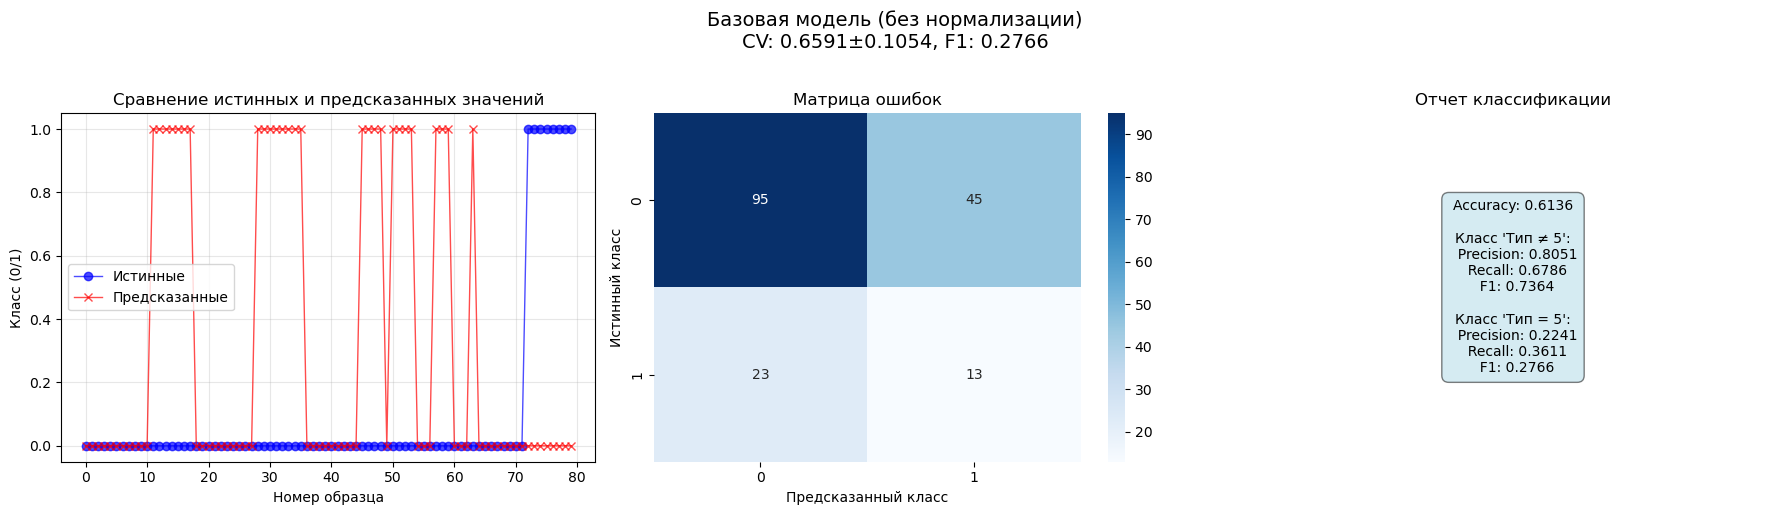

In [6]:
# ---------- БЛОК 3: БАЗОВАЯ МОДЕЛЬ БЕЗ ПРЕДОБРАБОТКИ ----------
if X_v1 is not None and y_v1 is not None:
    print("\n" + "="*70)
    print("БЛОК 3: БАЗОВАЯ МОДЕЛЬ (БЕЗ ПРЕДОБРАБОТКИ) - ПРИЗНАКИ V1")
    print("="*70)

    # Создание и оценка базовой модели
    base_model = MLPClassifier(
        hidden_layer_sizes=(50, 25),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        verbose=False
    )

    print("Оценка базовой модели без нормализации...")
    results_base = evaluate_model(X_v1, y_v1, base_model, cv=4)

    print(f"\nРезультаты базовой модели:")
    print(f"  CV (кросс-валидация): {results_base['cv_mean']:.4f} ± {results_base['cv_std']:.4f}")
    print(f"  Accuracy: {results_base['accuracy']:.4f}")
    print(f"  F1-score: {results_base['f1']:.4f}")

    # Визуализация результатов базовой модели
    plot_training_results(
        y_v1, 
        results_base['y_pred'],
        title="Базовая модель (без нормализации)",
        model_info=f"CV: {results_base['cv_mean']:.4f}±{results_base['cv_std']:.4f}, F1: {results_base['f1']:.4f}"
    )
else:
    print("Пропускаем Блок 3 - нет данных для работы")

### Эксперимент 3.2 - признаки V2


БЛОК 3: БАЗОВАЯ МОДЕЛЬ (БЕЗ ПРЕДОБРАБОТКИ) - ПРИЗНАКИ V2
Оценка базовой модели без нормализации...

Результаты базовой модели:
  CV (кросс-валидация): 0.7273 ± 0.0425
  Accuracy: 0.6080
  F1-score: 0.2737


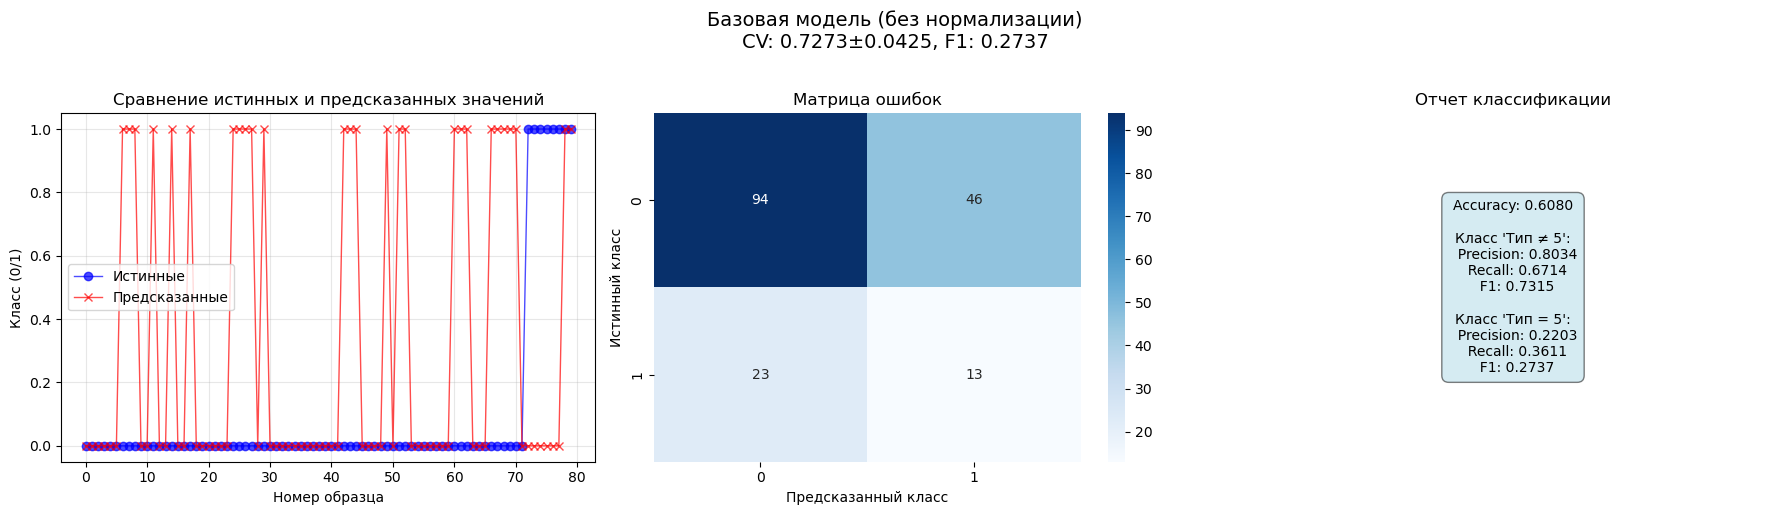

In [7]:
# ---------- БЛОК 3: БАЗОВАЯ МОДЕЛЬ БЕЗ ПРЕДОБРАБОТКИ ----------
if X_v2 is not None and y_v2 is not None:
    print("\n" + "="*70)
    print("БЛОК 3: БАЗОВАЯ МОДЕЛЬ (БЕЗ ПРЕДОБРАБОТКИ) - ПРИЗНАКИ V2")
    print("="*70)

    # Создание и оценка базовой модели
    base_model = MLPClassifier(
        hidden_layer_sizes=(50, 25),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        verbose=False
    )

    print("Оценка базовой модели без нормализации...")
    results_base = evaluate_model(X_v2, y_v2, base_model, cv=4)

    print(f"\nРезультаты базовой модели:")
    print(f"  CV (кросс-валидация): {results_base['cv_mean']:.4f} ± {results_base['cv_std']:.4f}")
    print(f"  Accuracy: {results_base['accuracy']:.4f}")
    print(f"  F1-score: {results_base['f1']:.4f}")

    # Визуализация результатов базовой модели
    plot_training_results(
        y_v2, 
        results_base['y_pred'],
        title="Базовая модель (без нормализации)",
        model_info=f"CV: {results_base['cv_mean']:.4f}±{results_base['cv_std']:.4f}, F1: {results_base['f1']:.4f}"
    )
else:
    print("Пропускаем Блок 3 - нет данных для работы")

### Эксперимент 3.3 - признаки V1 + V2


БЛОК 3: БАЗОВАЯ МОДЕЛЬ (БЕЗ ПРЕДОБРАБОТКИ) - ПРИЗНАКИ V1 + V2
Оценка базовой модели без нормализации...

Результаты базовой модели:
  CV (кросс-валидация): 0.7557 ± 0.0670
  Accuracy: 0.7898
  F1-score: 0.0513


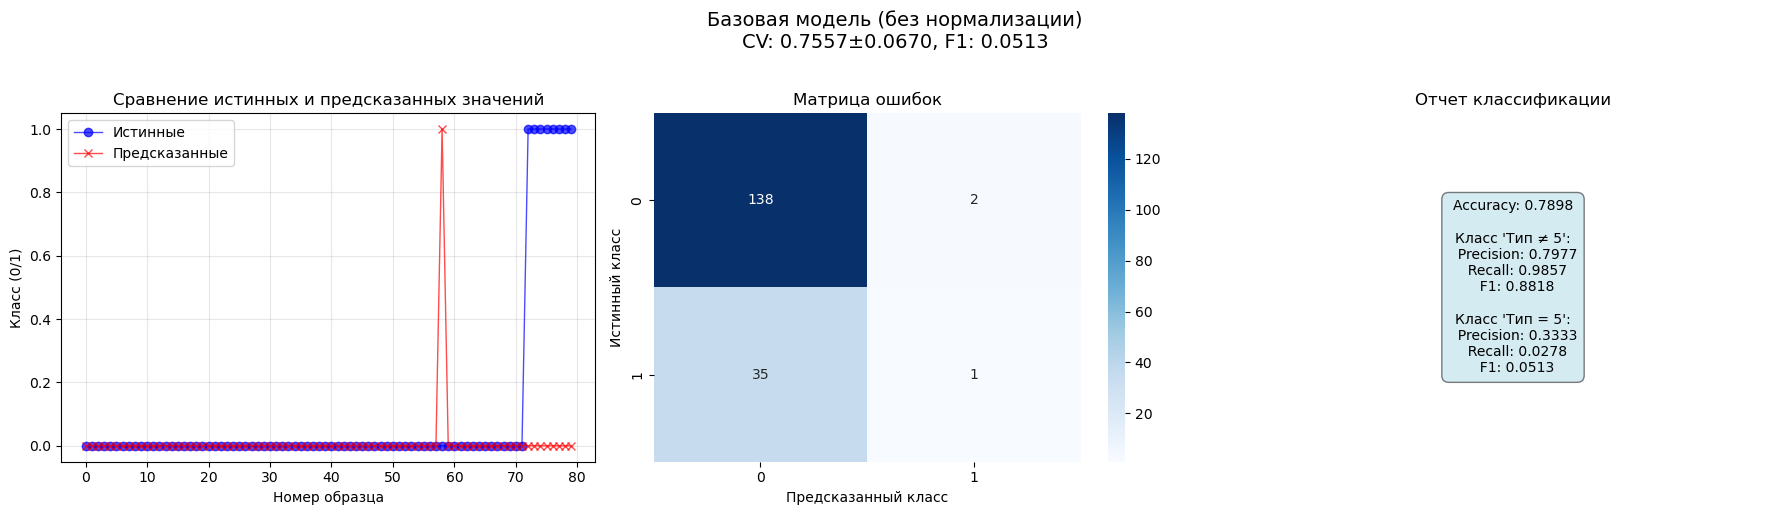

In [8]:
# ---------- БЛОК 3: БАЗОВАЯ МОДЕЛЬ БЕЗ ПРЕДОБРАБОТКИ ----------
if X is not None and y is not None:
    print("\n" + "="*70)
    print("БЛОК 3: БАЗОВАЯ МОДЕЛЬ (БЕЗ ПРЕДОБРАБОТКИ) - ПРИЗНАКИ V1 + V2")
    print("="*70)

    # Создание и оценка базовой модели
    base_model = MLPClassifier(
        hidden_layer_sizes=(50, 25),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        verbose=False
    )

    print("Оценка базовой модели без нормализации...")
    results_base = evaluate_model(X, y, base_model, cv=4)

    print(f"\nРезультаты базовой модели:")
    print(f"  CV (кросс-валидация): {results_base['cv_mean']:.4f} ± {results_base['cv_std']:.4f}")
    print(f"  Accuracy: {results_base['accuracy']:.4f}")
    print(f"  F1-score: {results_base['f1']:.4f}")

    # Визуализация результатов базовой модели
    plot_training_results(
        y, 
        results_base['y_pred'],
        title="Базовая модель (без нормализации)",
        model_info=f"CV: {results_base['cv_mean']:.4f}±{results_base['cv_std']:.4f}, F1: {results_base['f1']:.4f}"
    )
else:
    print("Пропускаем Блок 3 - нет данных для работы")

## **Выводы по пункту 3 - "Базовая модель без предобработки"**

In [9]:
results_table = pd.DataFrame({
    'Признаки': ['V1', 'V2', 'V1+V2'],
    'CV Accuracy': [0.6591, 0.7273, 0.7557],
    'Accuracy': [0.6136, 0.6080, 0.7898],
    'F1-score': [0.2766, 0.2737, 0.0513],
    'Recall (Тип 5)': [0.3611, 0.3611, 0.0278],
    'Precision (Тип 5)': [0.2241, 0.2203, 0.3333]
})

results_table

,Признаки,CV Accuracy,Accuracy,F1-score,Recall (Тип 5),Precision (Тип 5)
0,V1,0.6591,0.6136,0.2766,0.3611,0.2241
1,V2,0.7273,0.6080,0.2737,0.3611,0.2203
2,V1+V2,0.7557,0.7898,0.0513,0.0278,0.3333


1. Исследование показало, что:
- признаки V1 обеспечивают F1-score = 0.2766;
- признаки V2 обеспечивают F1-score = 0.2737;
- объединение признаков V1 и V2 без предварительной нормализации приводит к ухудшению качества распознавания целевого класса (F1-score = 0.0513).

2. Для задачи идентификации поверхности типа 5 показатель Accuracy оказывается недостаточно информативным из-за несбалансированности классов. Более показательными являются метрики Recall и F1-score.

3. Таким образом, на этапе базового эксперимента наилучшие результаты показали признаки V1, а признаки V2 продемонстрировали сопоставимую эффективность. Объединённый набор V1+V2 без дополнительной предобработки данных оказался неэффективным для обнаружения поверхности типа 5.

# **4. Исследование с нормализацией данных**

Часть 1 - ЭКСПЕРИМЕНТ С НОРМАЛИЗАЦИЕЙ ДАННЫХ

In [10]:
# ---------- БЛОК 4: НОРМАЛИЗАЦИЯ И СРАВНЕНИЕ V1, V2, V1+V2 ----------
if X is not None and y is not None:
    print("\n" + "="*70)
    print("БЛОК 4: НОРМАЛИЗАЦИЯ ДАННЫХ")
    print("="*70)

    configurations = [
        ((50, 25), 'relu', 'adam', 1000, "Базовая"),
        ((100, 50), 'relu', 'adam', 1000, "Больше нейронов"),
        ((50, 25), 'tanh', 'adam', 1000, "Функция tanh"),
        ((30, 15, 10), 'relu', 'adam', 1000, "3 скрытых слоя"),
        ((50, 25), 'relu', 'lbfgs', 1000, "Solver lbfgs")
    ]

    # словари для хранения нормализованных данных
    normalized_datasets = {}
    
    all_results = []
    for dataset_name, (X_current, y_current) in datasets.items():

        print("\n" + "-"*60)
        print(f"НАБОР ПРИЗНАКОВ: {dataset_name}")
        print("-"*60)

        print(X_current)
        # Нормализация данных
        scaler = MinMaxScaler()
        X_norm = scaler.fit_transform(X_current)
        
        # сохраняем для дальнейшего использования
        normalized_datasets[dataset_name] = {
        'X_norm': X_norm,
        'y': y_current,
        'scaler': scaler
        }

    
        print(
            f"Нормализация выполнена "
            f"[{X_norm.min():.2f}; {X_norm.max():.2f}]"
        )

        results_norm = []
        for i, (hidden_layers, activation,solver,max_iter,description) in enumerate(configurations, start=1):

            print(f"\nКонфигурация {i}: {description}")

            model = MLPClassifier(
                hidden_layer_sizes=hidden_layers,
                activation=activation,
                solver=solver,
                max_iter=max_iter,
                random_state=42
            )

            try:
               
                results = evaluate_model(
                    X_norm,
                    y_current,
                    model,
                    cv=4
                )

                all_results.append({
                    'Dataset': dataset_name,
                    'Config': description,
                    'Hidden Layers': hidden_layers,
                    'Activation': activation,
                    'Solver': solver,
                    'CV': results['cv_mean'],
                    'CV std': results['cv_std'],
                    'Accuracy': results['accuracy'],
                    'F1': results['f1'],
                    'model': results['model']
                })
                
                results_norm.append({
                    'config_id': i,
                    'description': description,
                    'hidden_layers': hidden_layers,
                    'activation': activation,
                    'solver': solver,
                    'max_iter': max_iter,
                    'cv_mean': results['cv_mean'],
                    'cv_std': results['cv_std'],
                    'accuracy': results['accuracy'],
                    'f1': results['f1'],
                    'model': results['model']
                })
    

                print(
                    f"CV={results['cv_mean']:.4f} | "
                    f"Accuracy={results['accuracy']:.4f} | "
                    f"F1={results['f1']:.4f}"
                )

            except Exception as e:
                print(f"Ошибка: {e}")
        
else:
    print("Пропускаем Блок 4 - нет данных для работы")

print(X_norm) 
results_df = pd.DataFrame(all_results)


БЛОК 4: НОРМАЛИЗАЦИЯ ДАННЫХ

------------------------------------------------------------
НАБОР ПРИЗНАКОВ: V1
------------------------------------------------------------
        N1     N2     N3      V1real      V2real      V3real        I1  \
0    -5070     30   5239 -249.352941    4.764706  265.235294  1.126697   
1    -5320     -9   5391 -260.470588    0.000000  263.647059  1.039215   
2    -4829      6   4786 -268.411765    0.000000  268.411765  0.911011   
3     2670  -5662   2875  141.352941 -306.529412  162.000000  0.692308   
4     2841  -5824   2967  155.647059 -314.470588  169.941176  0.529412   
..     ...    ...    ...         ...         ...         ...       ...   
171   5847   5663   5901  349.200000  340.200000  358.200000  0.288889   
172   6025   6018   6005  347.400000  343.800000  360.000000  0.314530   
173  12100  12073  12049  750.600000  739.800000  738.000000  0.287179   
174  12493  12493  12564  734.400000  745.200000  747.000000  0.370940   
175  11285  11

In [90]:
print(X_v1.shape)
print(X_v2.shape)
print(X_v1v2.shape)

print(X_norm.shape)

(176, 15)
(176, 7)
(176, 22)
(176, 22)


### Результаты для V1

In [91]:
display(
    results_df[
        results_df['Dataset'] == 'V1'
    ].round(4)
)

,Dataset,Config,Hidden Layers,Activation,Solver,CV,CV std,Accuracy,F1,model
0,V1,Базовая,"(50, 25)",relu,adam,0.8295,0.0377,0.9943,0.9859,"MLPClassifier(hidden_layer_sizes=(50, 25), max..."
1,V1,Больше нейронов,"(100, 50)",relu,adam,0.8295,0.0341,1.0000,1.0000,"MLPClassifier(hidden_layer_sizes=(100, 50), ma..."
2,V1,Функция tanh,"(50, 25)",tanh,adam,0.7955,0.0000,0.7955,0.0000,"MLPClassifier(activation='tanh', hidden_layer_..."
3,V1,3 скрытых слоя,"(30, 15, 10)",relu,adam,0.8409,0.0161,0.7955,0.0000,"MLPClassifier(hidden_layer_sizes=(30, 15, 10),..."
4,V1,Solver lbfgs,"(50, 25)",relu,lbfgs,0.8011,0.0760,1.0000,1.0000,"MLPClassifier(hidden_layer_sizes=(50, 25), max..."


### Результаты для V2

In [92]:
display(
    results_df[
        results_df['Dataset'] == 'V2'
    ].round(4)
)

,Dataset,Config,Hidden Layers,Activation,Solver,CV,CV std,Accuracy,F1,model
5,V2,Базовая,"(50, 25)",relu,adam,0.8239,0.0336,0.9318,0.8286,"MLPClassifier(hidden_layer_sizes=(50, 25), max..."
6,V2,Больше нейронов,"(100, 50)",relu,adam,0.7614,0.0410,0.9943,0.9863,"MLPClassifier(hidden_layer_sizes=(100, 50), ma..."
7,V2,Функция tanh,"(50, 25)",tanh,adam,0.7955,0.0000,0.7955,0.0000,"MLPClassifier(activation='tanh', hidden_layer_..."
8,V2,3 скрытых слоя,"(30, 15, 10)",relu,adam,0.8011,0.0670,0.9886,0.9722,"MLPClassifier(hidden_layer_sizes=(30, 15, 10),..."
9,V2,Solver lbfgs,"(50, 25)",relu,lbfgs,0.7727,0.0533,1.0000,1.0000,"MLPClassifier(hidden_layer_sizes=(50, 25), max..."


### Результаты для V1 + V2

In [93]:
display(
    results_df[
        results_df['Dataset'] == 'V1+V2'
    ].round(4)
)

,Dataset,Config,Hidden Layers,Activation,Solver,CV,CV std,Accuracy,F1,model
10,V1+V2,Базовая,"(50, 25)",relu,adam,0.8580,0.0670,1.0000,1.0000,"MLPClassifier(hidden_layer_sizes=(50, 25), max..."
11,V1+V2,Больше нейронов,"(100, 50)",relu,adam,0.8750,0.0469,1.0000,1.0000,"MLPClassifier(hidden_layer_sizes=(100, 50), ma..."
12,V1+V2,Функция tanh,"(50, 25)",tanh,adam,0.8466,0.0188,0.9716,0.9315,"MLPClassifier(activation='tanh', hidden_layer_..."
13,V1+V2,3 скрытых слоя,"(30, 15, 10)",relu,adam,0.8636,0.0682,1.0000,1.0000,"MLPClassifier(hidden_layer_sizes=(30, 15, 10),..."
14,V1+V2,Solver lbfgs,"(50, 25)",relu,lbfgs,0.8466,0.0650,1.0000,1.0000,"MLPClassifier(hidden_layer_sizes=(50, 25), max..."


### Часть 2 - ОТОБРАЖЕНИЕ РЕЗУЛЬТАТОВ ЭКСПЕРИМЕНТа С НОРМАЛИЗАЦИЕЙ ДАННЫХ

### График лучших F1

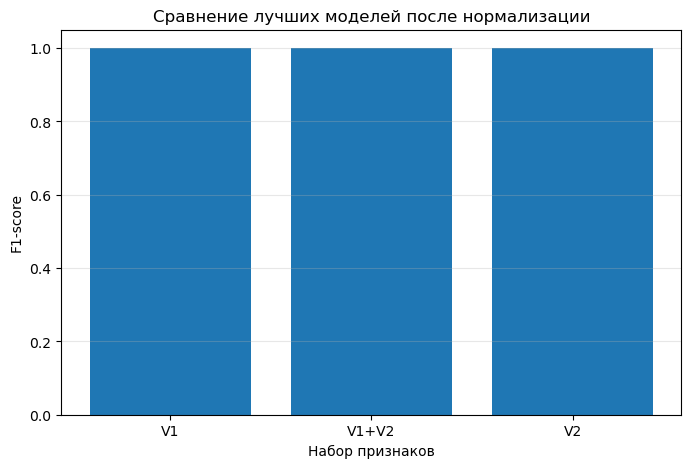

In [94]:
best_models = (
    results_df
    .sort_values('F1', ascending=False)
    .groupby('Dataset')
    .first()
    .reset_index()
)

best_models_dict = {}

for _, row in best_models.iterrows():

    best_models_dict[row['Dataset']] = {
        'model': row['model'],
        'accuracy': row['Accuracy'],
        'f1': row['F1'],
        'config': row['Config'],
        'cv_mean': row['CV'],
        'cv_std': row['CV std'],
        'description': row['Config']
    }     


plt.figure(figsize=(8,5))

plt.bar(
    best_models['Dataset'],
    best_models['F1']
)

plt.ylabel('F1-score')
plt.xlabel('Набор признаков')
plt.title('Сравнение лучших моделей после нормализации')
plt.grid(True, axis='y', alpha=0.3)

plt.show()

### Сравнение Accuracy

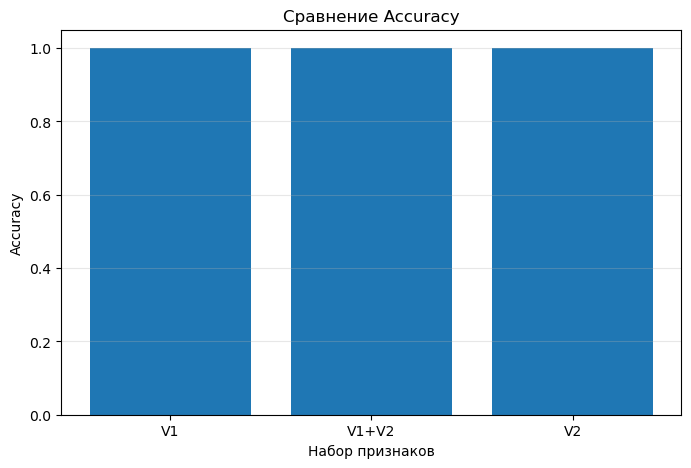

In [95]:
plt.figure(figsize=(8,5))

plt.bar(
    best_models['Dataset'],
    best_models['Accuracy']
)

plt.ylabel('Accuracy')
plt.xlabel('Набор признаков')
plt.title('Сравнение Accuracy')
plt.grid(True, axis='y', alpha=0.3)

plt.show()

### Сравнение CV

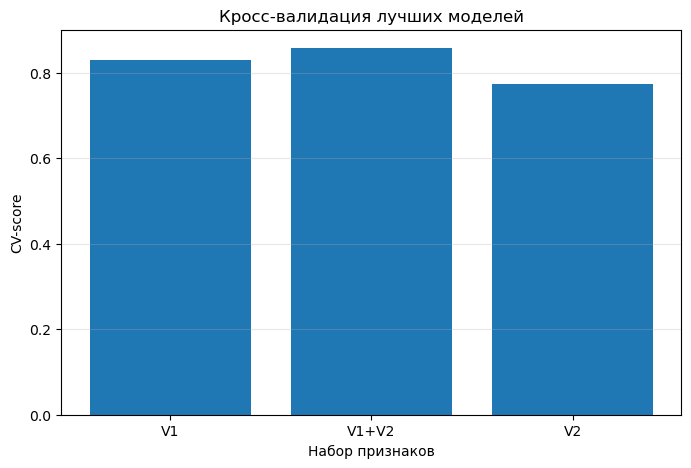

In [96]:
plt.figure(figsize=(8,5))

plt.bar(
    best_models['Dataset'],
    best_models['CV']
)

plt.ylabel('CV-score')
plt.xlabel('Набор признаков')
plt.title('Кросс-валидация лучших моделей')
plt.grid(True, axis='y', alpha=0.3)

plt.show()

### Влияние конфигурации сети для V1

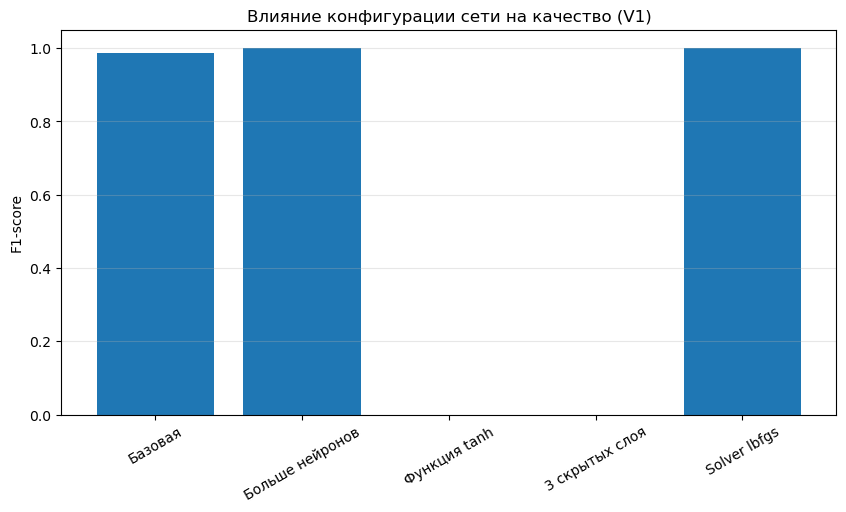

In [97]:
v1_results = results_df[
    results_df['Dataset'] == 'V1'
]

plt.figure(figsize=(10,5))

plt.bar(
    v1_results['Config'],
    v1_results['F1']
)

plt.title('Влияние конфигурации сети на качество (V1)')
plt.ylabel('F1-score')
plt.xticks(rotation=30)
plt.grid(True, axis='y', alpha=0.3)

plt.show()

### Влияние конфигурации сети для V2

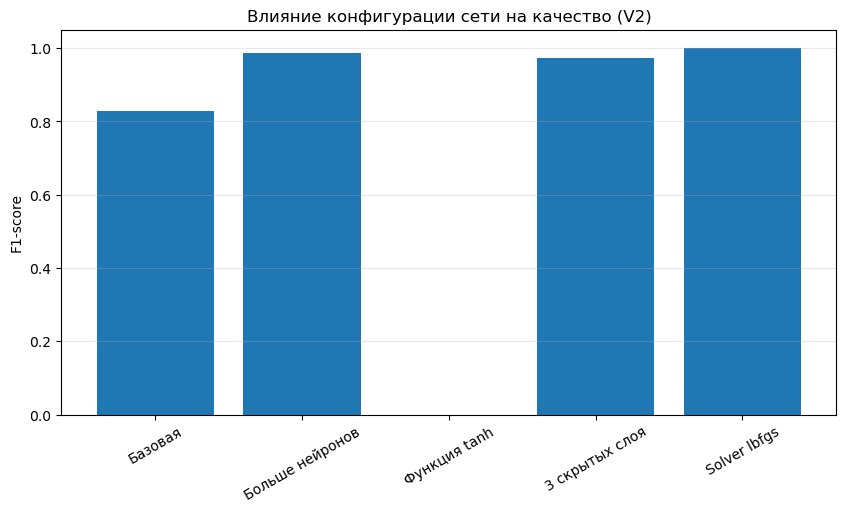

In [98]:
v2_results = results_df[
    results_df['Dataset'] == 'V2'
]

plt.figure(figsize=(10,5))

plt.bar(
    v2_results['Config'],
    v2_results['F1']
)

plt.title('Влияние конфигурации сети на качество (V2)')
plt.ylabel('F1-score')
plt.xticks(rotation=30)
plt.grid(True, axis='y', alpha=0.3)

plt.show()

### Влияние конфигурации сети для V1 + V2

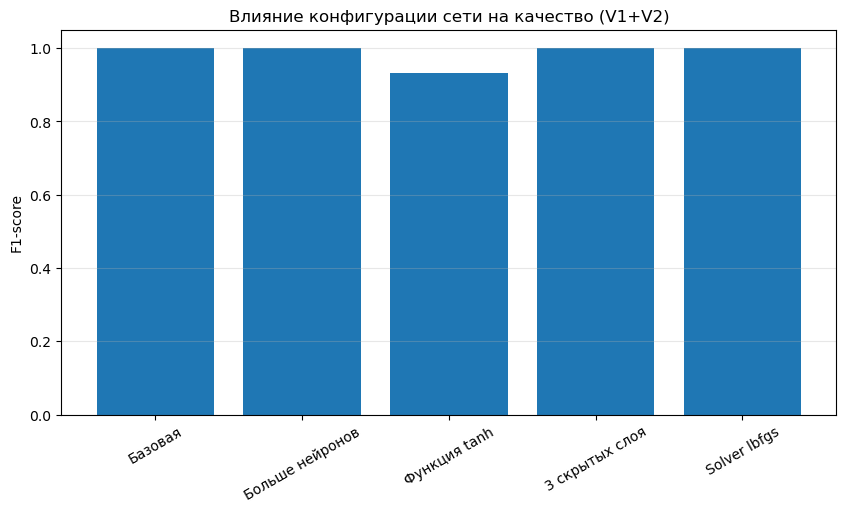

In [99]:
v1v2_results = results_df[
    results_df['Dataset'] == 'V1+V2'
]

plt.figure(figsize=(10,5))

plt.bar(
    v1v2_results['Config'],
    v1v2_results['F1']
)

plt.title('Влияние конфигурации сети на качество (V1+V2)')
plt.ylabel('F1-score')
plt.xticks(rotation=30)
plt.grid(True, axis='y', alpha=0.3)

plt.show()

## **Выводы по пункту 4 - "Исследование с нормализацией данных"**

### Сравнительная таблица моделей для V1, V2 и V1 + V2

In [100]:
display(results_df.round(4))

,Dataset,Config,Hidden Layers,Activation,Solver,CV,CV std,Accuracy,F1,model
0,V1,Базовая,"(50, 25)",relu,adam,0.8295,0.0377,0.9943,0.9859,"MLPClassifier(hidden_layer_sizes=(50, 25), max..."
1,V1,Больше нейронов,"(100, 50)",relu,adam,0.8295,0.0341,1.0000,1.0000,"MLPClassifier(hidden_layer_sizes=(100, 50), ma..."
2,V1,Функция tanh,"(50, 25)",tanh,adam,0.7955,0.0000,0.7955,0.0000,"MLPClassifier(activation='tanh', hidden_layer_..."
3,V1,3 скрытых слоя,"(30, 15, 10)",relu,adam,0.8409,0.0161,0.7955,0.0000,"MLPClassifier(hidden_layer_sizes=(30, 15, 10),..."
4,V1,Solver lbfgs,"(50, 25)",relu,lbfgs,0.8011,0.0760,1.0000,1.0000,"MLPClassifier(hidden_layer_sizes=(50, 25), max..."
5,V2,Базовая,"(50, 25)",relu,adam,0.8239,0.0336,0.9318,0.8286,"MLPClassifier(hidden_layer_sizes=(50, 25), max..."
6,V2,Больше нейронов,"(100, 50)",relu,adam,0.7614,0.0410,0.9943,0.9863,"MLPClassifier(hidden_layer_sizes=(100, 50), ma..."
7,V2,Функция tanh,"(50, 25)",tanh,adam,0.7955,0.0000,0.7955,0.0000,"MLPClassifier(activation='tanh', hidden_layer_..."
8,V2,3 скрытых слоя,"(30, 15, 10)",relu,adam,0.8011,0.0670,0.9886,0.9722,"MLPClassifier(hidden_layer_sizes=(30, 15, 10),..."
9,V2,Solver lbfgs,"(50, 25)",relu,lbfgs,0.7727,0.0533,1.0000,1.0000,"MLPClassifier(hidden_layer_sizes=(50, 25), max..."


### Cравнительная таблица лучших моделей для V1, V2 и V1 + V2

In [101]:
display(best_models.round(4))

,Dataset,Config,Hidden Layers,Activation,Solver,CV,CV std,Accuracy,F1,model
0,V1,Больше нейронов,"(100, 50)",relu,adam,0.8295,0.0341,1.0,1.0,"MLPClassifier(hidden_layer_sizes=(100, 50), ma..."
1,V1+V2,Базовая,"(50, 25)",relu,adam,0.8580,0.0670,1.0,1.0,"MLPClassifier(hidden_layer_sizes=(50, 25), max..."
2,V2,Solver lbfgs,"(50, 25)",relu,lbfgs,0.7727,0.0533,1.0,1.0,"MLPClassifier(hidden_layer_sizes=(50, 25), max..."


### Лучшая модель для V1

V1: (176, 15)
ЛУЧШАЯ МОДЕЛЬ V1
Dataset                                                         V1
Config                                             Больше нейронов
Hidden Layers                                            (100, 50)
Activation                                                    relu
Solver                                                        adam
CV                                                        0.829545
CV std                                                    0.034091
Accuracy                                                       1.0
F1                                                             1.0
model            MLPClassifier(hidden_layer_sizes=(100, 50), ma...
Name: 1, dtype: object


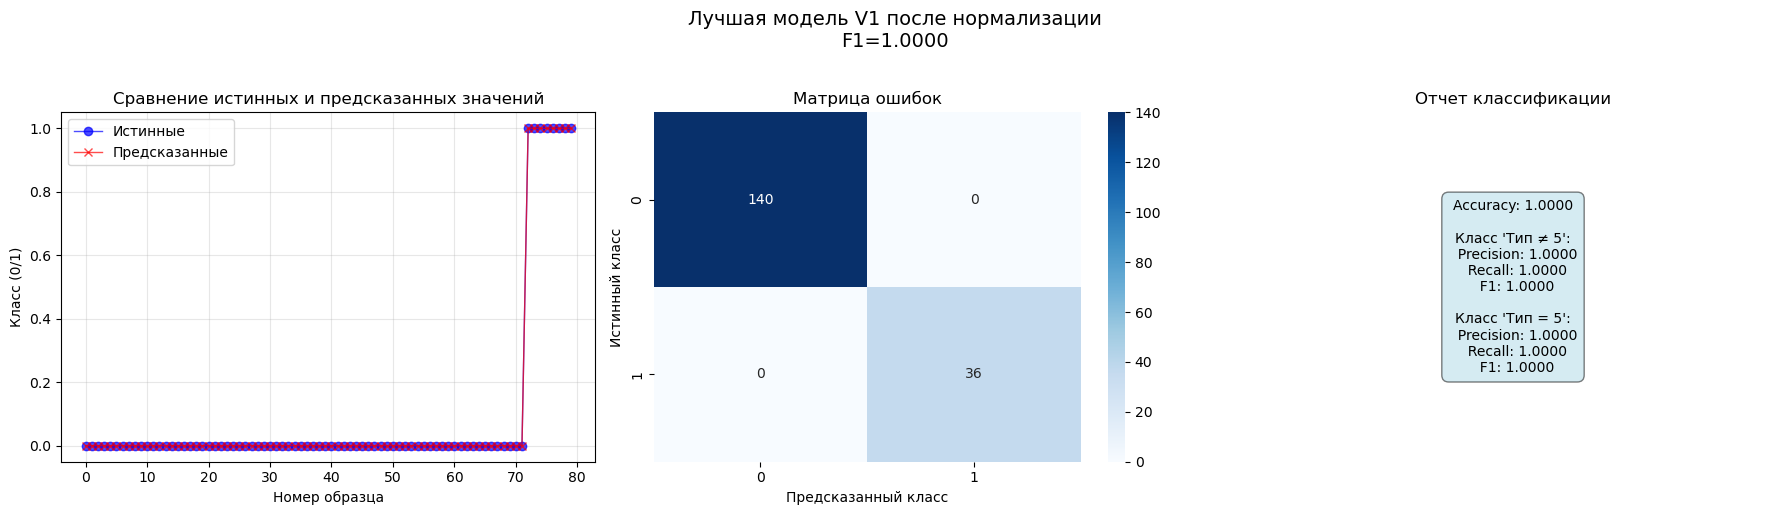

In [102]:
# ==========================================
# ЛУЧШАЯ МОДЕЛЬ V1
# ==========================================

X_v1_norm   = normalized_datasets['V1']['X_norm']
print("V1:", X_v1_norm.shape)

best_v1 = (
    results_df[results_df['Dataset'] == 'V1']
    .sort_values('F1', ascending=False)
    .iloc[0]
)

print("="*60)
print("ЛУЧШАЯ МОДЕЛЬ V1")
print("="*60)

print(best_v1)

model_v1 = MLPClassifier(
    hidden_layer_sizes=best_v1['Hidden Layers'],
    activation=best_v1['Activation'],
    solver=best_v1['Solver'],
    max_iter=1000,
    random_state=42
)

model_v1.fit(X_v1_norm, y_v1)

y_pred_v1 = model_v1.predict(X_v1_norm)

plot_training_results(
    y_v1,
    y_pred_v1,
    title="Лучшая модель V1 после нормализации",
    model_info=f"F1={best_v1['F1']:.4f}"
)
# Сохранение параметров лучшей модели V1
best_model_config_v1 = {
    'hidden_layers': best_v1['Hidden Layers'],
    'activation': best_v1['Activation'],
    'solver': best_v1['Solver'],
    'description': best_v1['Config']
}

# Сохранение метрик лучшей модели V1
best_norm_metrics_v1 = {
    'cv_mean': best_v1['CV'],
    'cv_std': best_v1['CV std'],
    'accuracy': best_v1['Accuracy'],
    'f1': best_v1['F1']
}

### Лучшая модель для V2

V2: (176, 7)
ЛУЧШАЯ МОДЕЛЬ V2
Dataset                                                         V2
Config                                                Solver lbfgs
Hidden Layers                                             (50, 25)
Activation                                                    relu
Solver                                                       lbfgs
CV                                                        0.772727
CV std                                                      0.0533
Accuracy                                                       1.0
F1                                                             1.0
model            MLPClassifier(hidden_layer_sizes=(50, 25), max...
Name: 9, dtype: object


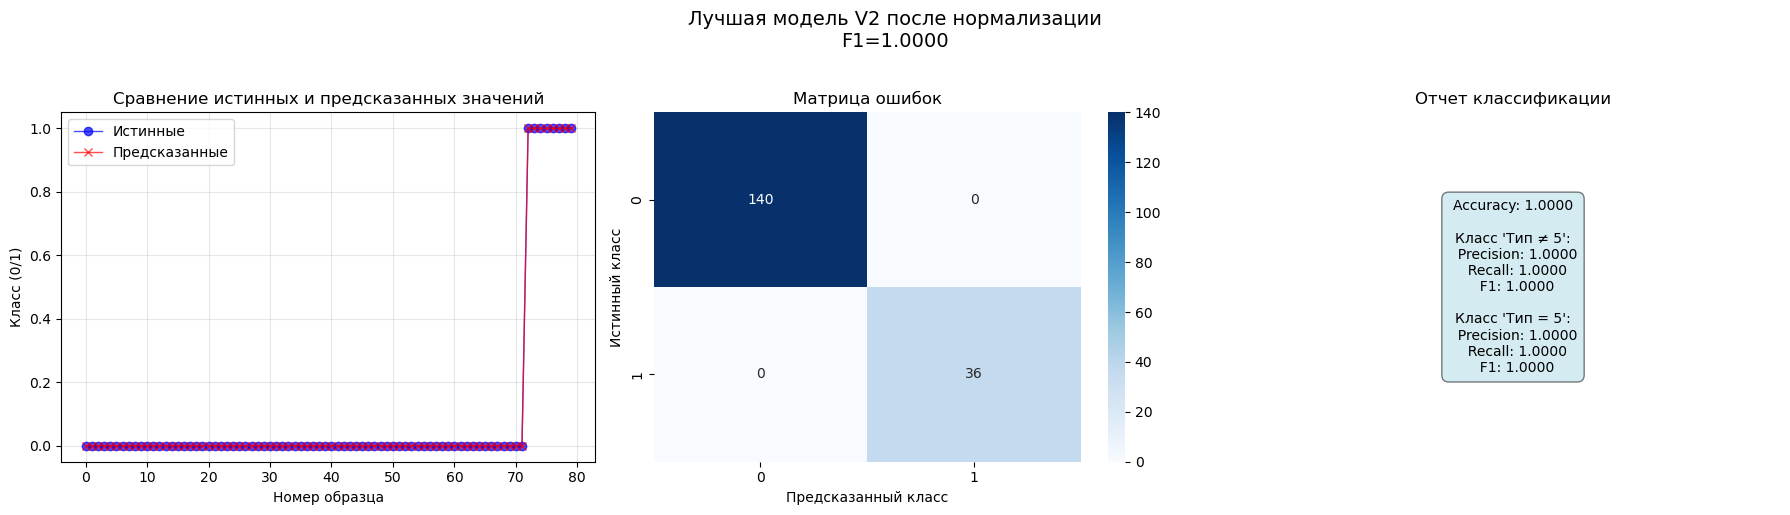

In [103]:
# ==========================================
# ЛУЧШАЯ МОДЕЛЬ V2
# ==========================================

X_v2_norm   = normalized_datasets['V2']['X_norm']
print("V2:", X_v2_norm.shape)

best_v2 = (
    results_df[results_df['Dataset'] == 'V2']
    .sort_values('F1', ascending=False)
    .iloc[0]
)

print("="*60)
print("ЛУЧШАЯ МОДЕЛЬ V2")
print("="*60)

print(best_v2)

model_v2 = MLPClassifier(
    hidden_layer_sizes=best_v2['Hidden Layers'],
    activation=best_v2['Activation'],
    solver=best_v2['Solver'],
    max_iter=1000,
    random_state=42
)

model_v2.fit(X_v2_norm, y_v2)

y_pred_v2 = model_v2.predict(X_v2_norm)

plot_training_results(
    y_v2,
    y_pred_v2,
    title="Лучшая модель V2 после нормализации",
    model_info=f"F1={best_v2['F1']:.4f}"
)
# Сохранение параметров лучшей модели V2
best_model_config_v2 = {
    'hidden_layers': best_v2['Hidden Layers'],
    'activation': best_v2['Activation'],
    'solver': best_v2['Solver'],
    'description': best_v2['Config']
}

# Сохранение метрик лучшей модели 2
best_norm_metrics_v2 = {
    'cv_mean': best_v2['CV'],
    'cv_std': best_v2['CV std'],
    'accuracy': best_v2['Accuracy'],
    'f1': best_v2['F1']
}

### Лучшая модель для V1 + V2

V1+V2: (176, 22)
ЛУЧШАЯ МОДЕЛЬ V1 + V2
Dataset                                                      V1+V2
Config                                                     Базовая
Hidden Layers                                             (50, 25)
Activation                                                    relu
Solver                                                        adam
CV                                                        0.857955
CV std                                                    0.066988
Accuracy                                                       1.0
F1                                                             1.0
model            MLPClassifier(hidden_layer_sizes=(50, 25), max...
Name: 10, dtype: object


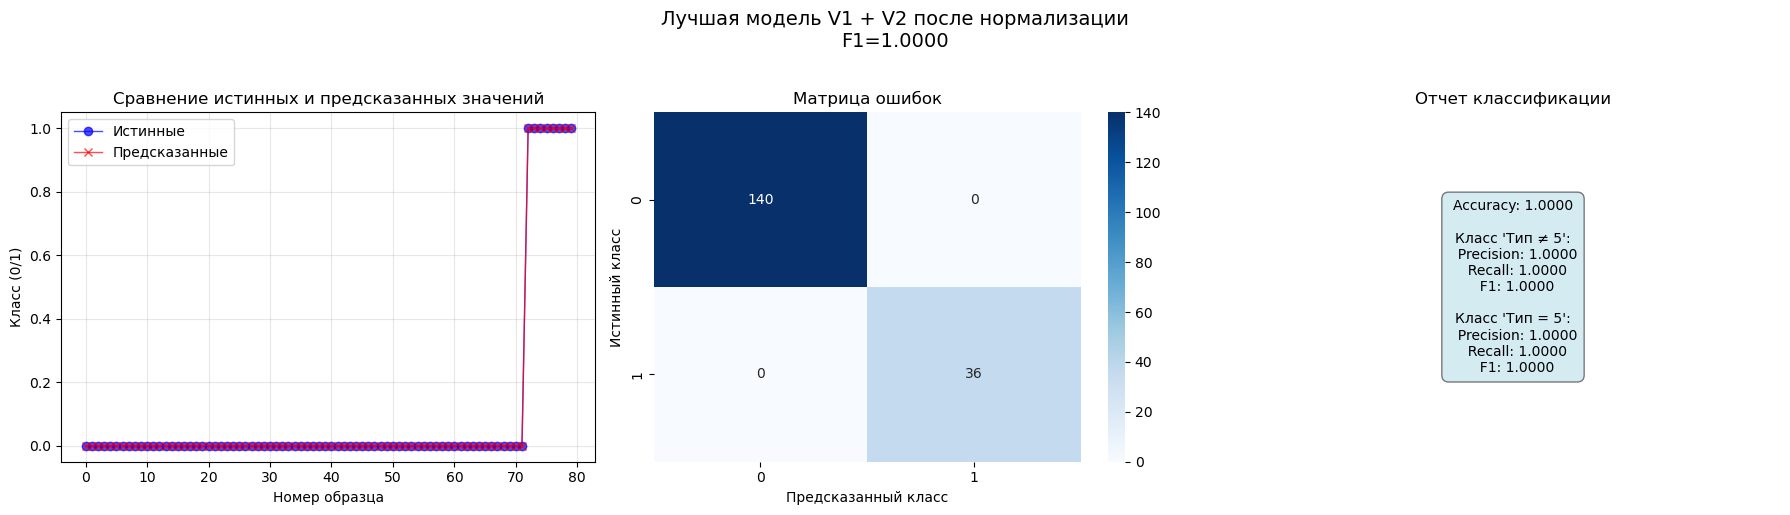

In [104]:
# ==========================================
# ЛУЧШАЯ МОДЕЛЬ V1 + V2
# ==========================================

X_v1v2_norm   = normalized_datasets['V1+V2']['X_norm']
print("V1+V2:", X_v1v2_norm.shape)

best_v1v2 = (
    results_df[results_df['Dataset'] == 'V1+V2']
    .sort_values('F1', ascending=False)
    .iloc[0]
)

print("="*60)
print("ЛУЧШАЯ МОДЕЛЬ V1 + V2")
print("="*60)

print(best_v1v2)

model_v1v2 = MLPClassifier(
    hidden_layer_sizes=best_v1v2['Hidden Layers'],
    activation=best_v1v2['Activation'],
    solver=best_v1v2['Solver'],
    max_iter=1000,
    random_state=42
)

model_v1v2.fit(X_v1v2_norm, y_v1v2)

y_pred_v1v2 = model_v1v2.predict(X_v1v2_norm)

plot_training_results(
    y_v1v2,
    y_pred_v1v2,
    title="Лучшая модель V1 + V2 после нормализации",
    model_info=f"F1={best_v1v2['F1']:.4f}"
)
# Сохранение параметров лучшей модели V1 + V2
best_model_config_v1v2 = {
    'hidden_layers': best_v1v2['Hidden Layers'],
    'activation': best_v1v2['Activation'],
    'solver': best_v1v2['Solver'],
    'description': best_v1v2['Config']
}


# **5. Тестирование на выборке С**

### Часть 1 - загрузка выборки С

In [105]:
print("\n" + "="*70)
print("БЛОК 5: ТЕСТИРОВАНИЕ НА ВЫБОРКЕ C")
print("="*70)

try:
    data_c_paths = [
        Path('../Data/Data_Set_C.xlsx'),
        Path('Data/Data_Set_C.xlsx')
    ]

    data_c = None
    for path in data_c_paths:

        if path.exists():

            data_c = pd.read_excel(path)

            print(f"✓ Выборка C загружена: {path}")
            print(f"Размер: {data_c.shape}")

            break
    
    print(f"✓ Данные загружены: {data_c.shape[0]} строк, {data_c.shape[1]} столбцов")
    print(f"  Столбцы: {list(data_c.columns)}")

    # Добавляем переменные V2 к общей Dataframe
    data_c = calculate_v2_features(data_c)
    print(f"✓ Новые данные загружены: {data_c.shape[0]} строк, {data_c.shape[1]} столбцов")
    print(f"  Столбцы: {list(data_c.columns)}")
    
    # Показываем первые 5 строк данных
    print("\n" + "="*50)
    print("ПЕРВЫЕ 5 СТРОК ДАННЫХ:")
    print("="*50)
    print(data_c.head())
    
    # Показываем последние 5 строк данных
    print("\n" + "="*50)
    print("ПОСЛЕДНИЕ 5 СТРОК ДАННЫХ:")
    print("="*50)
    print(data_c.tail())
    
    
    if data_c is None:
        raise FileNotFoundError(
            "Файл Data_Set_C.xlsx не найден"
        )

except Exception as e:
    print("Ошибка:", e)


БЛОК 5: ТЕСТИРОВАНИЕ НА ВЫБОРКЕ C
✓ Выборка C загружена: ..\Data\Data_Set_C.xlsx
Размер: (58, 16)
✓ Данные загружены: 58 строк, 16 столбцов
  Столбцы: ['I1', 'I2', 'I3', 'gx', 'gy', 'gz', 'ax', 'ay', 'az', 'V1real', 'V2real', 'V3real', 'N1', 'N2', 'N3', 'Type']
✓ Новые данные загружены: 58 строк, 23 столбцов
  Столбцы: ['I1', 'I2', 'I3', 'gx', 'gy', 'gz', 'ax', 'ay', 'az', 'V1real', 'V2real', 'V3real', 'N1', 'N2', 'N3', 'Type', 'Vx', 'Vy', 'Omega', 'Ix', 'Iy', 'Iphi', 'Isum']

ПЕРВЫЕ 5 СТРОК ДАННЫХ:
         I1        I2        I3        gx        gy         gz        ax  \
0  1.143286  0.016591  1.073907  0.343529 -0.032941   0.185294  0.018899   
1  0.499246  1.135747  0.481146  0.654118  0.263529  -1.826471  0.009004   
2  0.351433  0.874811  0.942685  0.845882  0.114118  -3.032941  0.016070   
3  0.333333  0.459566  0.258382  0.533077 -1.130769  16.233077 -0.008263   
4  0.347008  0.353846  0.336752  0.093333 -1.026667  34.422667 -0.003776   

         ay        az      V1real  ..

### Часть 2 - подготовка признаков

In [106]:
Xc_v1, yc_v1 = prepare_data_v1(
    data_c,
    target_type=5
)

Xc_v2, yc_v2 = prepare_data_v2(
    data_c,
    target_type=5
)

Xc_v1v2, yc_v1v2 = prepare_data_v1v2(
    data_c,
    target_type=5
)

# Словарь наборов
test_datasets = {
    'V1': (Xc_v1, yc_v1, normalized_datasets['V1']['scaler']),

    'V2': (Xc_v2, yc_v2, normalized_datasets['V2']['scaler']),

    'V1+V2': (Xc_v1v2, yc_v1v2, normalized_datasets['V1+V2']['scaler'])
}

### Часть 3 - Тестирование

In [107]:
print(best_models_dict.keys())

dict_keys(['V1', 'V1+V2', 'V2'])



ТЕСТИРОВАНИЕ V1
Accuracy = 0.8966
F1       = 0.7500


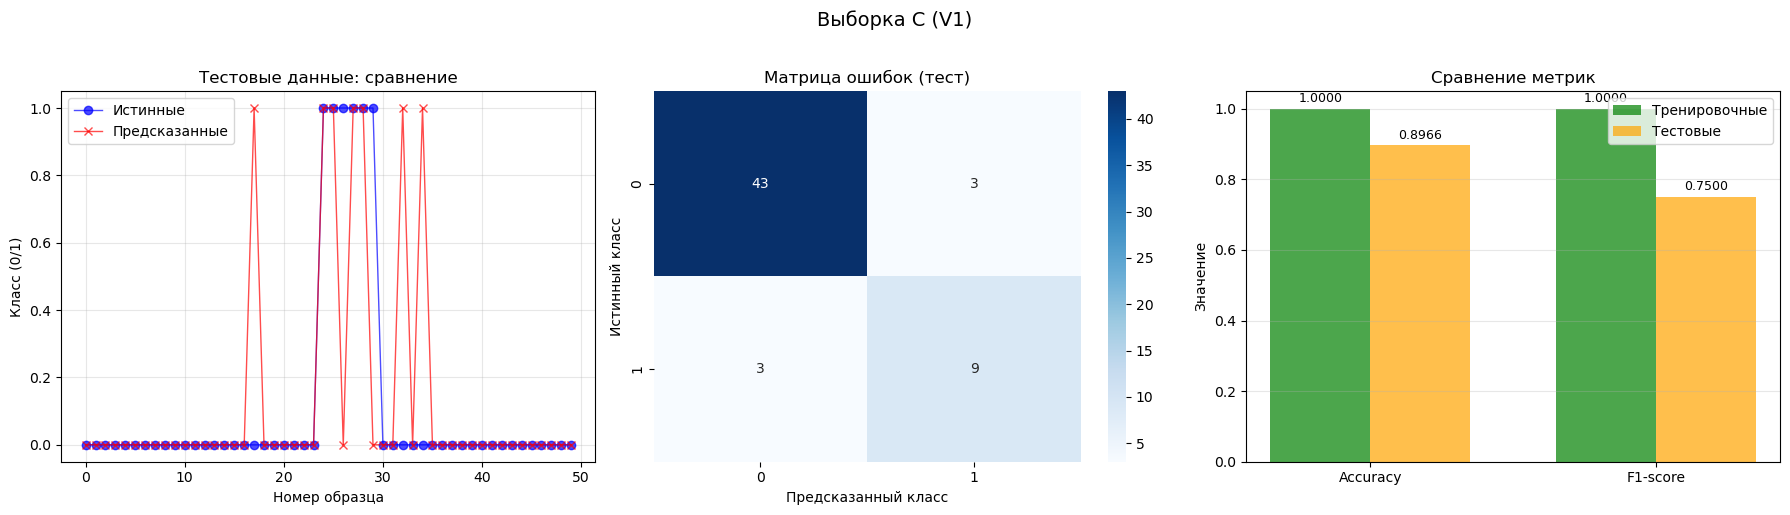


ТЕСТИРОВАНИЕ V2
Accuracy = 0.8793
F1       = 0.7200


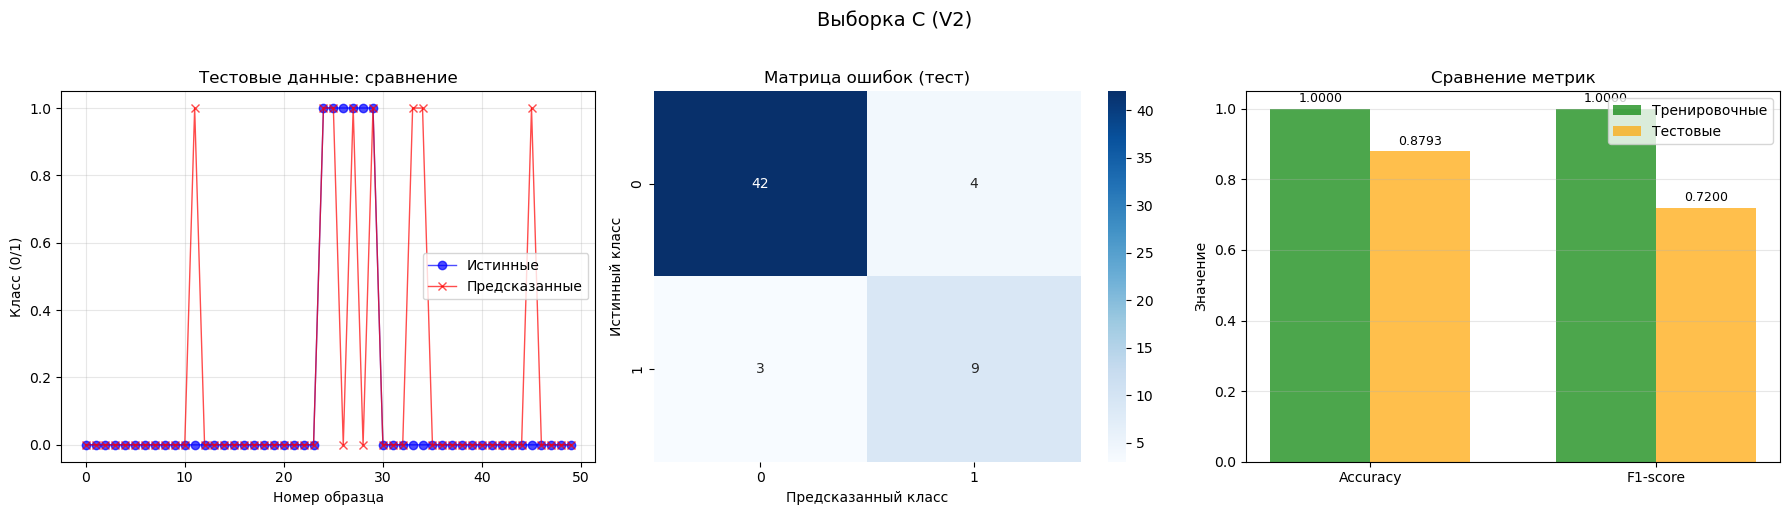


ТЕСТИРОВАНИЕ V1+V2
Accuracy = 0.9138
F1       = 0.8000


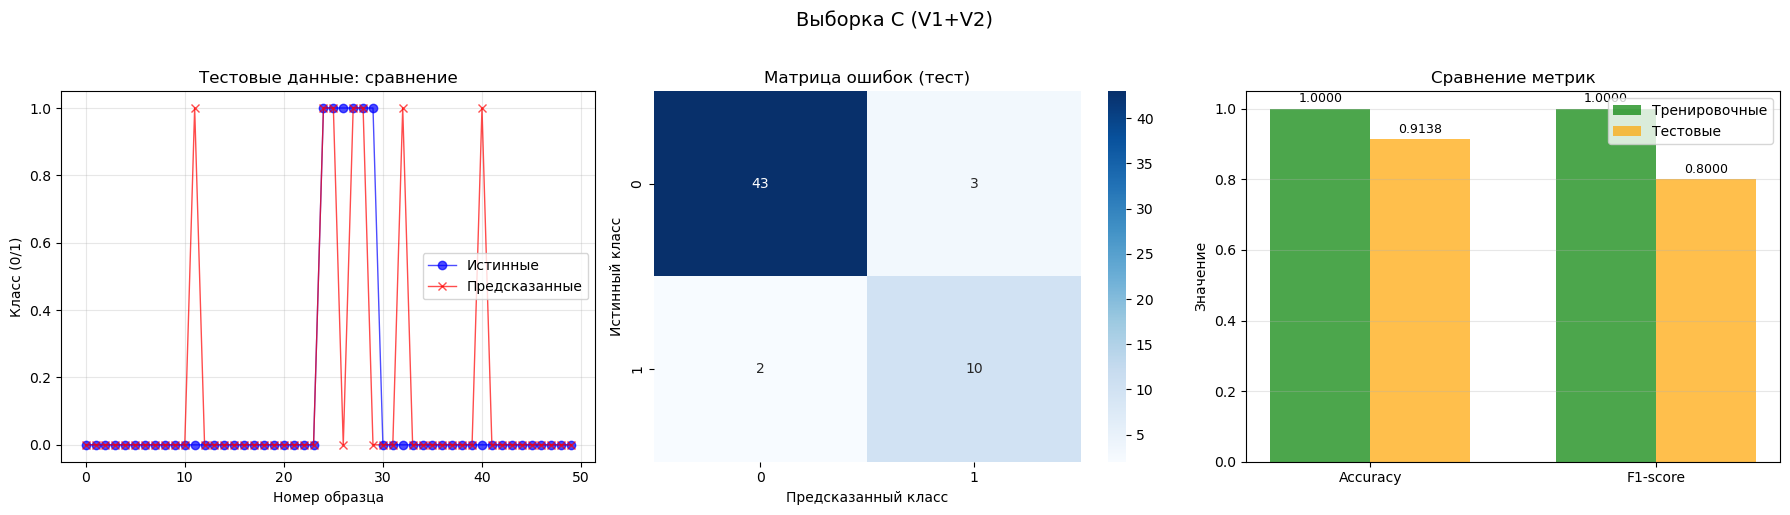

In [108]:
test_results = {}
for dataset_name, (X_test, y_test, scaler) in test_datasets.items():

    print("\n" + "="*60)
    print(f"ТЕСТИРОВАНИЕ {dataset_name}")
    print("="*60)

    X_test_norm = scaler.transform(X_test)

    model = best_models_dict[dataset_name]['model']
    
    y_pred = model.predict(X_test_norm)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    print(f"Accuracy = {accuracy:.4f}")
    print(f"F1       = {f1:.4f}")

    test_metrics = {
        'accuracy': accuracy,
        'f1': f1
    }

    train_metrics = {
        'accuracy':
            best_models_dict[dataset_name]['accuracy'],

        'f1':
            best_models_dict[dataset_name]['f1']
    }
    
    test_results[dataset_name] = {
    'accuracy': accuracy,
    'f1': f1
    }
    
    

    plot_test_results(
        y_test,
        y_pred,
        train_metrics,
        test_metrics,
        title=f"Выборка C ({dataset_name})"
    )

### Часть 4 - выводы

In [109]:
# ---------- ДЕТАЛЬНЫЙ АНАЛИЗ V1, V2 и V1+V2 ----------

print("\n" + "="*70)
print("ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ НА ВЫБОРКЕ C")
print("="*70)

analysis_datasets = {
    'V1': (Xc_v1, yc_v1),
    'V2': (Xc_v2, yc_v2),
    'V1+V2': (Xc_v1v2, yc_v1v2)
}

for dataset_name, (X_test, y_test) in analysis_datasets.items():

    print("\n" + "="*60)
    print(f"НАБОР ПРИЗНАКОВ: {dataset_name}")
    print("="*60)

    try:

        model = best_models_dict[dataset_name]['model']

        scaler = normalized_datasets[dataset_name]['scaler']

        X_test_norm = scaler.transform(X_test)

        y_pred = model.predict(X_test_norm)

        # Метрики
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        print(f"\nAccuracy = {accuracy:.4f}")
        print(f"F1-score = {f1:.4f}")

        # Матрица ошибок
        cm = confusion_matrix(y_test, y_pred)

        print("\nМатрица ошибок:")
        print(cm)

        # Classification Report
        print("\nОтчет классификации:")
        print(
            classification_report(
                y_test,
                y_pred,
                target_names=[
                    'Тип ≠ 5',
                    'Тип = 5'
                ]
            )
        )

    except Exception as e:
        print(f"Ошибка: {e}")


ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ НА ВЫБОРКЕ C

НАБОР ПРИЗНАКОВ: V1

Accuracy = 0.8966
F1-score = 0.7500

Матрица ошибок:
[[43  3]
 [ 3  9]]

Отчет классификации:
              precision    recall  f1-score   support

     Тип ≠ 5       0.93      0.93      0.93        46
     Тип = 5       0.75      0.75      0.75        12

    accuracy                           0.90        58
   macro avg       0.84      0.84      0.84        58
weighted avg       0.90      0.90      0.90        58


НАБОР ПРИЗНАКОВ: V2

Accuracy = 0.8793
F1-score = 0.7200

Матрица ошибок:
[[42  4]
 [ 3  9]]

Отчет классификации:
              precision    recall  f1-score   support

     Тип ≠ 5       0.93      0.91      0.92        46
     Тип = 5       0.69      0.75      0.72        12

    accuracy                           0.88        58
   macro avg       0.81      0.83      0.82        58
weighted avg       0.88      0.88      0.88        58


НАБОР ПРИЗНАКОВ: V1+V2

Accuracy = 0.9138
F1-score = 0.8000

Матрица о

# **6. Заключение**

In [110]:
test_metrics

{'accuracy': 0.9137931034482759, 'f1': 0.8}

In [111]:
# ---------- БЛОК 6: ИТОГОВЫЕ ВЫВОДЫ ----------

print("\n" + "="*70)
print("БЛОК 6: ИТОГОВЫЕ ВЫВОДЫ И РЕЗУЛЬТАТЫ")
print("="*70)

print("\nОСНОВНЫЕ РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТОВ")

for dataset_name in ['V1', 'V2', 'V1+V2']:

    print("\n" + "-"*60)
    print(f"НАБОР ПРИЗНАКОВ: {dataset_name}")
    print("-"*60)

    # Лучшая модель
    best_model = best_models_dict[dataset_name]

    print("\nЛучшая конфигурация:")
    print(f"  Конфигурация : {best_model['config']}")
    print(f"  CV среднее   : {best_model['cv_mean']:.4f}")
    print(f"  CV std       : {best_model['cv_std']:.4f}")
    print(f"  Accuracy     : {best_model['accuracy']:.4f}")
    print(f"  F1-score     : {best_model['f1']:.4f}")

    # Тестовые результаты
    if dataset_name in test_results:

        print("\nРезультаты на выборке C:")

        print(
            f"  Accuracy : "
            f"{test_results[dataset_name]['accuracy']:.4f}"
        )

        print(
            f"  F1-score : "
            f"{test_results[dataset_name]['f1']:.4f}"
        )


БЛОК 6: ИТОГОВЫЕ ВЫВОДЫ И РЕЗУЛЬТАТЫ

ОСНОВНЫЕ РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТОВ

------------------------------------------------------------
НАБОР ПРИЗНАКОВ: V1
------------------------------------------------------------

Лучшая конфигурация:
  Конфигурация : Больше нейронов
  CV среднее   : 0.8295
  CV std       : 0.0341
  Accuracy     : 1.0000
  F1-score     : 1.0000

Результаты на выборке C:
  Accuracy : 0.8966
  F1-score : 0.7500

------------------------------------------------------------
НАБОР ПРИЗНАКОВ: V2
------------------------------------------------------------

Лучшая конфигурация:
  Конфигурация : Solver lbfgs
  CV среднее   : 0.7727
  CV std       : 0.0533
  Accuracy     : 1.0000
  F1-score     : 1.0000

Результаты на выборке C:
  Accuracy : 0.8793
  F1-score : 0.7200

------------------------------------------------------------
НАБОР ПРИЗНАКОВ: V1+V2
------------------------------------------------------------

Лучшая конфигурация:
  Конфигурация : Базовая
  CV среднее   : 

In [112]:
summary_results = []

for dataset_name in ['V1', 'V2', 'V1+V2']:

    summary_results.append({

        'Dataset': dataset_name,

        # Без нормализации
        'Base CV':
            base_results_dict[dataset_name]['cv_mean'],

        'Base F1':
            base_results_dict[dataset_name]['f1'],

        'Base Accuracy':
            base_results_dict[dataset_name]['accuracy'],

        # После нормализации
        'Norm CV':
            best_models_dict[dataset_name]['cv_mean'],

        'Norm F1':
            best_models_dict[dataset_name]['f1'],

        'Norm Accuracy':
            best_models_dict[dataset_name]['accuracy'],

        # Выборка С
        'Test F1':
            test_results[dataset_name]['f1'],

        'Test Accuracy':
            test_results[dataset_name]['accuracy']
    })

summary_df = pd.DataFrame(summary_results)

display(summary_df)

,Dataset,Base CV,Base F1,Base Accuracy,Norm CV,Norm F1,Norm Accuracy,Test F1,Test Accuracy
0,V1,0.659091,0.276596,0.613636,0.829545,1.0,1.0,0.75,0.896552
1,V2,0.727273,0.273684,0.607955,0.772727,1.0,1.0,0.72,0.879310
2,V1+V2,0.755682,0.051282,0.789773,0.857955,1.0,1.0,0.80,0.913793


In [113]:
best_dataset = summary_df.loc[
    summary_df['Test F1'].idxmax(),
    'Dataset'
]

best_f1 = summary_df['Test F1'].max()

print("\n" + "="*70)
print("ОБЩИЙ ВЫВОД")
print("="*70)

print(
    f"\nЛучшие результаты показал набор признаков "
    f"{best_dataset}."
)

print(
    f"На независимой выборке C был достигнут "
    f"F1-score = {best_f1:.4f}."
)

print(
    "\nСравнение показало, что объединение "
    "исходных признаков V1 и интегральных "
    "признаков V2 обеспечивает наиболее "
    "качественную классификацию поверхности 5."
)

print(
    "\nТаким образом, совместное использование "
    "V1 и V2 является предпочтительным для "
    "решения задачи распознавания типа поверхности."
)


ОБЩИЙ ВЫВОД

Лучшие результаты показал набор признаков V1+V2.
На независимой выборке C был достигнут F1-score = 0.8000.

Сравнение показало, что объединение исходных признаков V1 и интегральных признаков V2 обеспечивает наиболее качественную классификацию поверхности 5.

Таким образом, совместное использование V1 и V2 является предпочтительным для решения задачи распознавания типа поверхности.


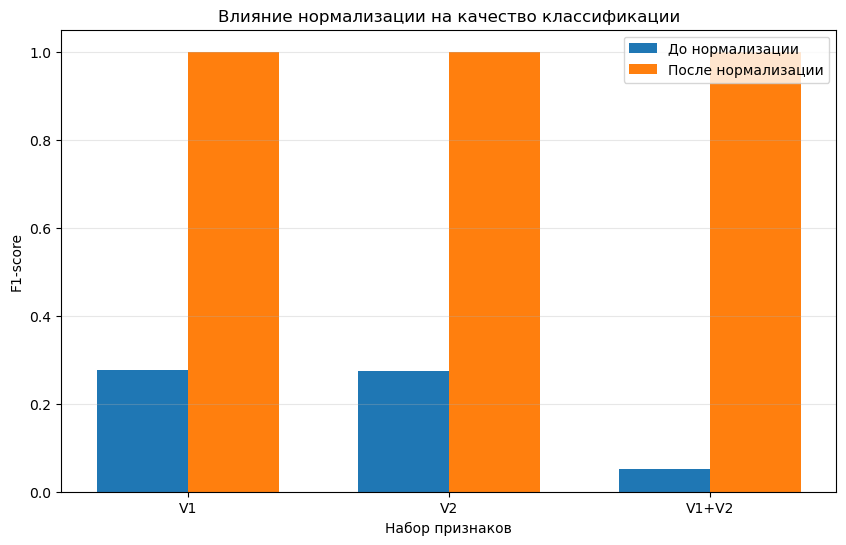

In [114]:
import matplotlib.pyplot as plt
import numpy as np

datasets = summary_df['Dataset']

base_f1 = summary_df['Base F1']
norm_f1 = summary_df['Norm F1']

x = np.arange(len(datasets))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x - width/2,
    base_f1,
    width,
    label='До нормализации'
)

plt.bar(
    x + width/2,
    norm_f1,
    width,
    label='После нормализации'
)

plt.xticks(x, datasets)

plt.ylabel('F1-score')
plt.xlabel('Набор признаков')
plt.title('Влияние нормализации на качество классификации')

plt.legend()
plt.grid(True, axis='y', alpha=0.3)

plt.show()

## Выводы
1. Нормализация данных оказывает положительное влияние на качество классификации.
2. Признаки V2 содержат полезную информацию о взаимодействии робота с поверхностью, однако не могут полностью заменить исходные признаки V1.
3. Наиболее информативным оказался объединённый набор признаков V1+V2.
4. Использование вычисленных интегральных характеристик совместно с исходными измерениями позволяет повысить качество распознавания типа поверхности.
5. Тестирование на независимой выборке C подтвердило устойчивость разработанной модели.